# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to analyze the cleaned e-commerce datasets, identify patterns, visualize trends, understand customer behavior, and generate business insights that will help build an effective hybrid recommendation system.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display all columns
pd.set_option("display.max_columns", None)

# Better chart style
plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================
# Load Cleaned Datasets
# ==========================================

products = pd.read_csv("processed/products_clean.csv")
reviews = pd.read_csv("processed/reviews_clean.csv")
electronics = pd.read_csv("processed/electronics_clean.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# ==========================================
# Dataset Shape
# ==========================================

print("Products Dataset :", products.shape)
print("Reviews Dataset :", reviews.shape)
print("Electronics Dataset :", electronics.shape)

Products Dataset : (728, 34)
Reviews Dataset : (6327, 23)
Electronics Dataset : (1292954, 10)


In [4]:
# ==========================================
# Display Sample Data
# ==========================================

display(products.head())

display(reviews.head())

display(electronics.head())

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1,default_variant/2,delivery_date,fastest_delivery_date,list_price,manufacturer,model_number,price_value,product_description,product_url,rating_count,rating_distribution/1star,rating_distribution/2star,rating_distribution/3star,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
0,0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",MLYENX Store,https://www.amazon.com/stores/MLYENX/page/1FCD...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirts comfortable and well...,size:Large,"color:5 Pack Black, Dark Grey, Light Blue, Mil...",NaN,"Saturday, March 15","Tomorrow, March 11",List Price: $53.99,Unknown,Unknown,39.9926,No Description Available,https://www.amazon.com/dp/B0B59BJG6Y,0,2%,1%,7%,15%,75%,4.6,50+ bought,03-10-2025 21:42,Greenfive,https://www.amazon.com/gp/help/seller/at-a-gla...,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,['https://m.media-amazon.com/images/I/41yUF65P...,85.0
1,1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",COOFANDY Store,https://www.amazon.com/stores/COOFANDY/page/23...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",NaN,size:X-Large,color:Light Grey,NaN,"Saturday, March 15","Tomorrow, March 11",Typical price: $24.99,Unknown,Unknown,19.9920,No Description Available,https://www.amazon.com/dp/B0DLGB4RYH,0,0%,6%,11%,17%,66%,4.4,NaN,03-10-2025 21:42,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,['https://m.media-amazon.com/images/I/31a3mSs3...,199.0
2,2,"PERFORMANCE:These men polo shirts are soft,lig...",B0DRXF62JH,In Stock,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",ZITY Store,https://www.amazon.com/stores/ZITY/page/F582B6...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",NaN,size:X-Large,color:Bblack Grey Navy,NaN,"Saturday, March 15","Wednesday, March 12",List Price: $59.99,Unknown,Unknown,29.9950,No Description Available,https://www.amazon.com/dp/B0DRXF62JH,0,0%,0%,0%,37%,63%,4.6,NaN,03-10-2025 21:42,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,['https://m.media-amazon.com/images/I/41J5q-Ua...,111.0
3,3,【Material】: These golf shirts for men are made...,B0DK5FZ325,In Stock,"#194,649 in Clothing, Shoes & Jewelry (See Top...",Rouen Store,https://www.amazon.com/stores/ROUEN/page/4C407...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",NaN,size:Small,color:Light Pink Stripe,NaN,"Saturday, March 15","Wednesday, March 12",NaN,Unknown,Unknown,32.9500,No Description Available,https://www.amazon.com/dp/B0DK5FZ325,0,0%,0%,0%,20%,80%,4.8,NaN,03-10-2025 21:43,MICHEL ROUEN,https://www.amazon.com/gp/help/seller/at-a-gla...,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,['https://m.media-amazon.com/images/I/31J1ttvf...,266.0
4,4,MOISTURE WICKING: The fabric of the summer gol...,B0BGXTC1FR,In Stock,"#3,664 in Clothing, Shoes & Jewelry (See Top 1...",V VALANCH Store,https://www.amazon.com/stores/VVALANCH/page/0E...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirt has a good fit and lo...,size:X-Large,color:A-moonblue,NaN,"Saturday, March 15","Tomorrow, March 11",List Price: $38.99,Unknown,Unknown,26.9931,No Description Available,https://www.amazon.com/dp/B0BGXTC1FR,0,5%,2%,7%,17%,69%,4.4,NaN,03-10-2025 21:43,Zhengdaqian,https://www.amazon.com/gp/help/seller/at-a-gla...,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,['https://m.media-amazon.com/images/I/31Ff+3Ib...,11.0


,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,productASIN,productVariant,rating,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DLGB4RYH,Color: BlackSize: X-Large,5.0,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Bblack Grey NavySize: 3X-Large,5.0,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Grey Navy DuckblueSize: Medium,4.0,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Black Duckblue WineredSize: X-Large,5.0,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0DRXF62JH,Color: Bblack Grey NavySize: X-Large,5.0,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4,With these three polo shirts I was very satisf...,Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material go...,0.250000


,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0


In [5]:
# ==========================================
# Statistical Summary
# ==========================================

products.describe()

,s.no,price_value,rating_count,rating_stars,rank_1
count,728.000000,728.000000,728.0,728.000000,540.000000
mean,423.361264,35.140084,0.0,4.385165,174.622222
std,293.923401,26.059801,0.0,0.328474,240.115097
min,0.000000,5.457300,0.0,1.000000,1.000000
25%,184.750000,19.990000,0.0,4.300000,18.000000
50%,371.500000,28.950000,0.0,4.400000,56.500000
75%,553.250000,40.006700,0.0,4.600000,220.250000
max,1011.000000,249.990000,0.0,5.000000,994.000000


In [6]:
products.describe(include="object")

,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1,default_variant/2,delivery_date,fastest_delivery_date,list_price,manufacturer,model_number,product_description,product_url,rating_distribution/1star,rating_distribution/2star,rating_distribution/3star,rating_distribution/4star,rating_distribution/5star,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images
count,728,728,715,558,728,649,715,634,696,658,1,702,667,401,728,728,728,728,728,728,728,728,728,569,728,707,426,728,728
unique,697,728,11,539,285,237,140,616,118,413,1,51,33,205,132,192,239,728,34,19,24,33,63,19,120,267,426,704,714
top,"Textured fabric that's soft, light & breathabl...",B0B59BJG6Y,In Stock,"#67 in Clothing, Shoes & Jewelry (See Top 100 ...",Hanes Store,https://www.amazon.com/stores/Hanes/page/F8302...,"Clothing, Shoes & Jewelry › Men › Clothing › J...",Customers find the shirt has a good fit and st...,size:Large,color:Black,color:Team Red/Black/Team Red Viper,"Saturday, March 15","Tomorrow, March 11",List Price: $39.99,Unknown,Unknown,No Description Available,https://www.amazon.com/dp/B0B59BJG6Y,3%,2%,6%,15%,75%,100+ bought,03-10-2025 22:38,Amazon.com,https://www.amazon.com/gp/help/seller/at-a-gla...,Under Armour Men's Tech Golf Polo,['https://m.media-amazon.com/images/I/31mfMfV8...
freq,3,1,640,3,35,35,52,3,168,106,1,610,491,10,462,529,457,1,123,194,107,89,44,108,18,278,1,3,2


In [7]:
products.info()
reviews.info()
electronics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   s.no                       728 non-null    int64  
 1   about_item                 728 non-null    object 
 2   asin                       728 non-null    object 
 3   availability               715 non-null    object 
 4   best_sellers_rank          558 non-null    object 
 5   brand_name                 728 non-null    object 
 6   brand_page_url             649 non-null    object 
 7   breadcrumbs                715 non-null    object 
 8   customer_review_summary    634 non-null    object 
 9   default_variant/0          696 non-null    object 
 10  default_variant/1          658 non-null    object 
 11  default_variant/2          1 non-null      object 
 12  delivery_date              702 non-null    object 
 13  fastest_delivery_date      667 non-null    object 

In [8]:
# ==========================================
# Missing Values
# ==========================================

products.isnull().sum()

s.no                           0
about_item                     0
asin                           0
availability                  13
best_sellers_rank            170
brand_name                     0
brand_page_url                79
breadcrumbs                   13
customer_review_summary       94
default_variant/0             32
default_variant/1             70
default_variant/2            727
delivery_date                 26
fastest_delivery_date         61
list_price                   327
manufacturer                   0
model_number                   0
price_value                    0
product_description            0
product_url                    0
rating_count                   0
rating_distribution/1star      0
rating_distribution/2star      0
rating_distribution/3star      0
rating_distribution/4star      0
rating_distribution/5star      0
rating_stars                   0
recent_purchases             159
scrape_time                    0
seller_name                   21
seller_pag

In [9]:
products.isnull().sum().sum()

np.int64(2282)

In [10]:
# Missing values in each column
missing_values = products.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

default_variant/2          727
list_price                 327
seller_page_url            302
rank_1                     188
best_sellers_rank          170
recent_purchases           159
customer_review_summary     94
brand_page_url              79
default_variant/1           70
fastest_delivery_date       61
default_variant/0           32
delivery_date               26
seller_name                 21
availability                13
breadcrumbs                 13
dtype: int64

In [11]:
# ==========================================
# Select Important Columns
# ==========================================

products_clean = products[
    [
        "asin",
        "title",
        "brand_name",
        "breadcrumbs",
        "product_description",
        "price_value",
        "rating_stars",
        "rating_count"
    ]
].copy()

products_clean.head()

,asin,title,brand_name,breadcrumbs,product_description,price_value,rating_stars,rating_count
0,B0B59BJG6Y,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,MLYENX Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",No Description Available,39.9926,4.6,0
1,B0DLGB4RYH,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,COOFANDY Store,"Clothing, Shoes & Jewelry › Men › Clothing › S...",No Description Available,19.9920,4.4,0
2,B0DRXF62JH,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,ZITY Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",No Description Available,29.9950,4.6,0
3,B0DK5FZ325,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,Rouen Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",No Description Available,32.9500,4.8,0
4,B0BGXTC1FR,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,V VALANCH Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",No Description Available,26.9931,4.4,0


In [12]:
products_clean.isnull().sum()

asin                    0
title                   0
brand_name              0
breadcrumbs            13
product_description     0
price_value             0
rating_stars            0
rating_count            0
dtype: int64

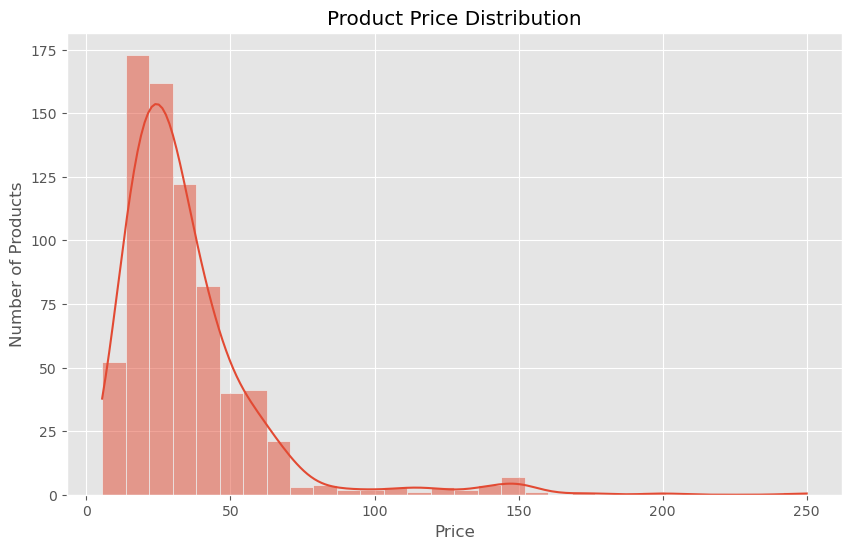

In [13]:
# ==========================================
# Product Price Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(products["price_value"], bins=30, kde=True)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

### Observation

- Most products are concentrated in the lower price range.
- Only a small number of premium-priced products exist.
- The distribution is right-skewed.

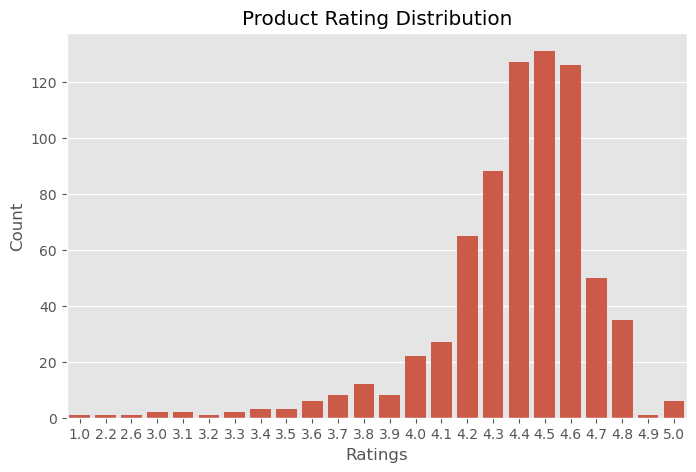

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=products, x="rating_stars")

plt.title("Product Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

### Observation

- Most products have ratings between 4.0 and 5.0.
- Very few products have low ratings.
- This indicates that Amazon products generally receive positive customer feedback.

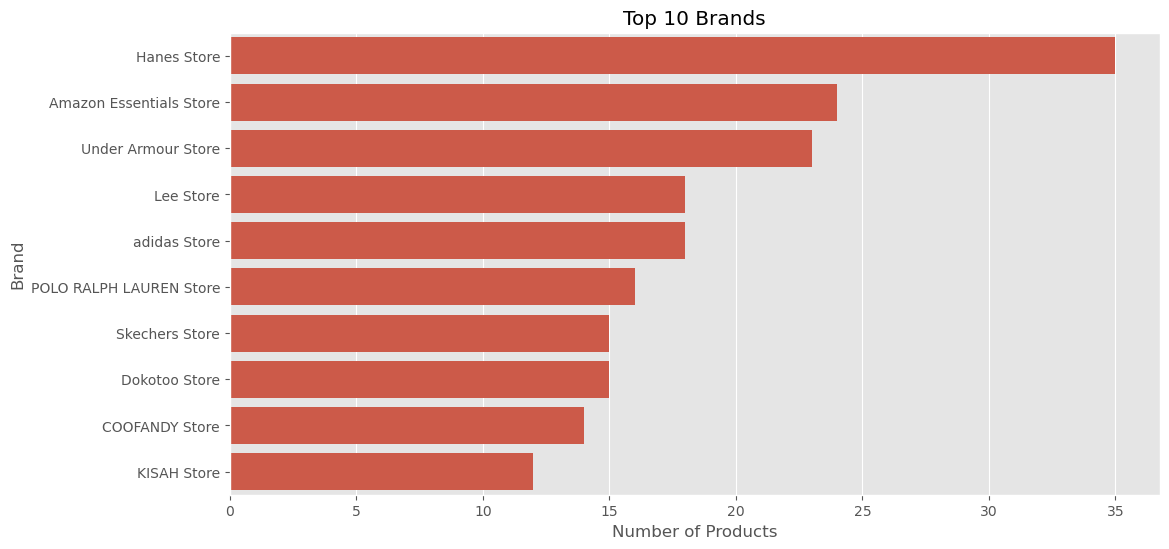

In [15]:
top_brands = products["brand_name"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 10 Brands")

plt.xlabel("Number of Products")

plt.ylabel("Brand")

plt.show()

In [16]:
products["breadcrumbs"].head()

0    Clothing, Shoes & Jewelry › Men › Clothing › A...
1    Clothing, Shoes & Jewelry › Men › Clothing › S...
2    Clothing, Shoes & Jewelry › Men › Clothing › A...
3    Clothing, Shoes & Jewelry › Men › Clothing › A...
4    Clothing, Shoes & Jewelry › Men › Clothing › A...
Name: breadcrumbs, dtype: object

C:\Users\Aman Tiwari\AppData\Local\Temp\ipykernel_22088\2725031203.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


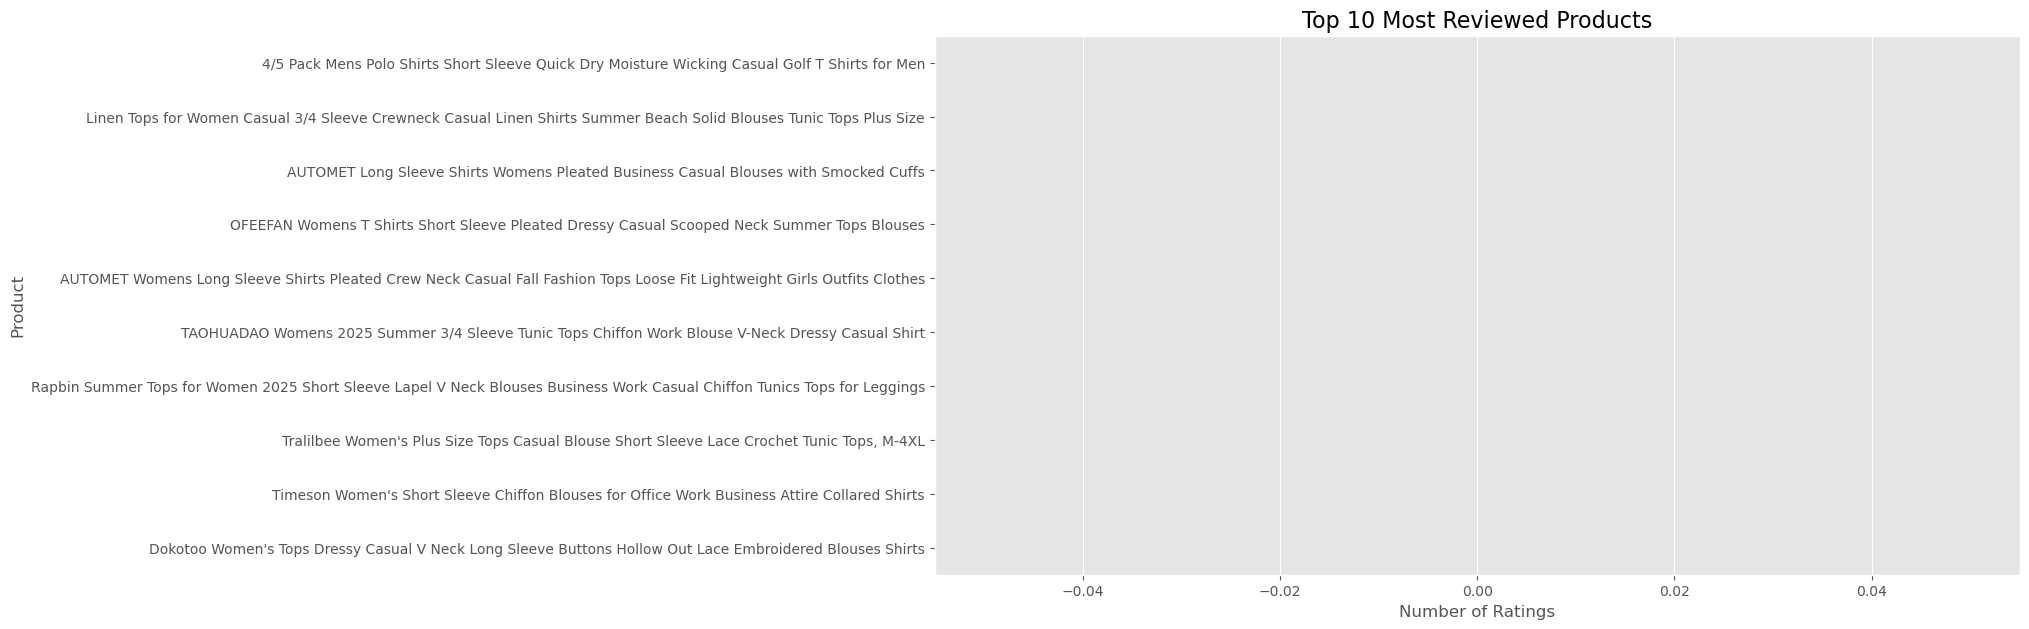

In [18]:
# ==========================================
# Top 10 Most Reviewed Products
# ==========================================

top_reviewed = (
    products_clean
    .sort_values("rating_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=top_reviewed,
    x="rating_count",
    y="title",
    palette="crest"
)

plt.title("Top 10 Most Reviewed Products", fontsize=16)
plt.xlabel("Number of Ratings")
plt.ylabel("Product")

plt.show()

### Observation

- The products with the highest number of ratings are generally the most popular.
- Highly reviewed products provide more reliable customer feedback.
- Such products are good candidates for recommendation systems.

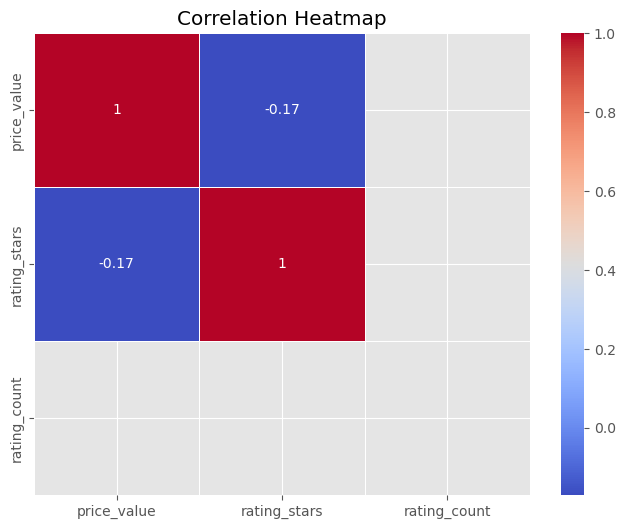

In [19]:
# ==========================================
# Correlation Heatmap
# ==========================================

numeric_columns = [
    "price_value",
    "rating_stars",
    "rating_count"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    products_clean[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows the strength of relationships between numerical features.
- Correlation values close to 1 indicate a strong positive relationship.
- Correlation values close to 0 indicate little or no linear relationship.

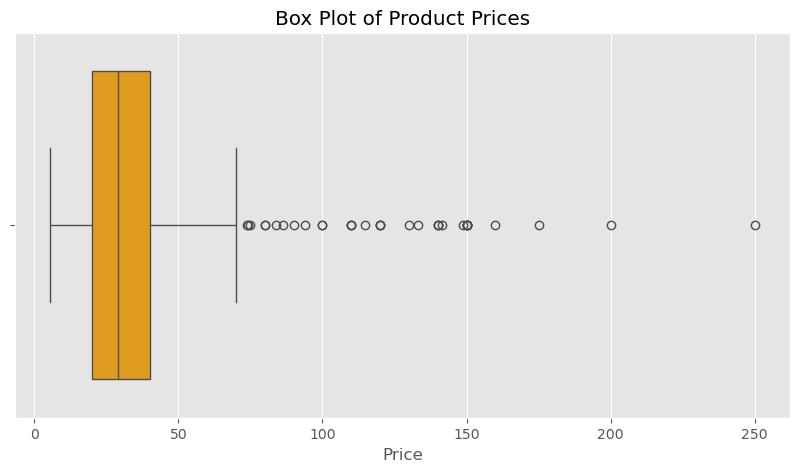

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=products_clean["price_value"],
    color="orange"
)

plt.title("Box Plot of Product Prices")
plt.xlabel("Price")

plt.show()

### Observation

- The box plot highlights the distribution of product prices.
- Several products have unusually high prices, appearing as outliers.
- Most products are concentrated within a smaller price range.